In [260]:
#Imports for data exploration
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [261]:
#Loading in data for exploration
df = pd.read_csv('Astro_Final_Dataset.csv', low_memory=False) #Recieved an error saying to add low_memory=False
df_missing = df[['a', 'e', 'i', 'diameter', 'albedo', 'BV', 'UB', 'IR', 'spec_B']].isnull().sum()

print('Columns', df.columns)
print('Stats', df.describe())
print('Missing Values', df_missing)

Columns Index(['a', 'e', 'i', 'diameter', 'albedo', 'BV', 'UB', 'IR', 'spec_B',
       'spec_T'],
      dtype='object')
Stats                    a              e              i       diameter  \
count  887103.000000  887103.000000  887103.000000  135464.000000   
mean        2.794469       0.139989       8.817910       5.561351   
std         3.482976       0.074890       6.114802       9.424598   
min         0.555300       0.000100       0.010000       0.083000   
25%         2.415000       0.083900       4.210000       2.843000   
50%         2.676000       0.132900       7.400000       4.028000   
75%         3.027000       0.186300      12.060000       5.808000   
max      1389.000000       0.993300     175.980000     939.400000   

              albedo           BV          UB    IR  
count  134541.000000  1021.000000  979.000000  1.00  
mean        0.131703     0.769212    0.364396 -0.33  
std         0.111132     0.088625    0.095780   NaN  
min         0.001000     0.580000   

In [262]:
#Dropping data that doesn't have the composition class labeled
df_labeled = df.dropna(subset=['spec_B']).copy()

print('Number of asteroids with classification labels:', len(df_labeled))

Number of asteroids with classification labels: 1618


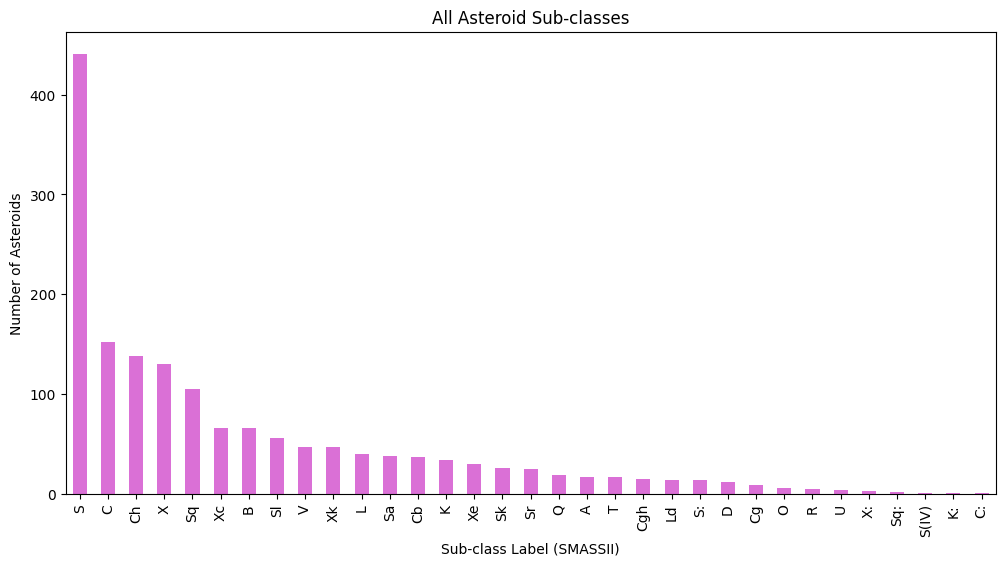

In [263]:
#Histogram of the data and all sub-classes labeled
plt.figure(figsize=(12, 6))
df['spec_B'].value_counts().plot(kind='bar', color='orchid')
plt.title('All Asteroid Sub-classes')
plt.xlabel('Sub-class Label (SMASSII)')
plt.ylabel('Number of Asteroids')
plt.show()

In [264]:
#Using a dictionary to re-label into the main three classifications
#Used the cmap dictionary shown in the chapter 3 homework to group the classes
mapping_dict = {'C': 'C-type', 'Ch': 'C-type', 'B': 'C-type', 'Cb': 'C-type', 'Cgh': 'C-type', 'Cg': 'C-type', 'C:': 'C-type',
                'S': 'S-type', 'Sq': 'S-type', 'Sl': 'S-type', 'Sa': 'S-type', 'Sk': 'S-type', 'Sr': 'S-type', 'S:': 'S-type', 
                'Sq:': 'S-type', 'S(IV)': 'S-type', 'A': 'S-type', 'Q': 'S-type', 'R': 'S-type', 'K': 'S-type', 'K:': 'S-type', 'L': 'S-type',
                'X': 'M-type', 'Xc': 'M-type', 'Xe': 'M-type', 'Xk': 'M-type', 'X:': 'M-type'}

#Use the .map() function to apply this dictionary to your column
df_labeled['main_classes'] = df_labeled['spec_B'].map(mapping_dict)

#Dropping the data that didn't fit into the 3 main classes
df_grouped = df_labeled.dropna(subset=['main_classes'])

#Printing new number of values
print('Rows with labels and mapped classes:', len(df_grouped))

Rows with labels and mapped classes: 1518


In [265]:
#Defining the features dropped IR because it only had one value
features = ['a', 'e', 'i', 'diameter', 'albedo', 'BV', 'UB']

#Dropping rows that have missing values
df_no_nans = df_grouped.dropna(subset=features).copy()

#Printing all the new values
print('Rows after dropping missing feature values:', len(df_no_nans))

print('Final Class Distribution:', df_no_nans['main_classes'].value_counts())

Rows after dropping missing feature values: 440
Final Class Distribution: main_classes
S-type    194
C-type    149
M-type     97
Name: count, dtype: int64


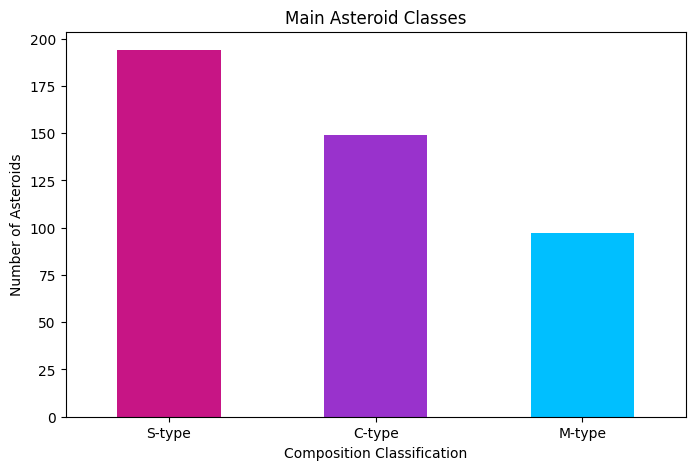

In [266]:
#Plotting new historgam or the main classes
plt.figure(figsize=(8, 5))
df_no_nans['main_classes'].value_counts().plot(kind='bar', color=['mediumvioletred', 'darkorchid', 'deepskyblue'])
plt.title('Main Asteroid Classes')
plt.ylabel('Number of Asteroids')
plt.xlabel('Composition Classification')
plt.xticks(rotation=0)
plt.show()

In [267]:
#Now I will apply the model, I'm using a decision tree and I will visualize it
#Imports to do this
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics

In [268]:
#Features are defined in a previous cell
#Defining the features and target for train and test split
X = df_no_nans[features]
y = df_no_nans['main_classes']

#Making the train and test split, ran a couple times to determine the best split 70/30 or 80/20, 80/20 is better
#Random state for reproducability
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [269]:
#Initialize my model and fit to the train the decision tree
#
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

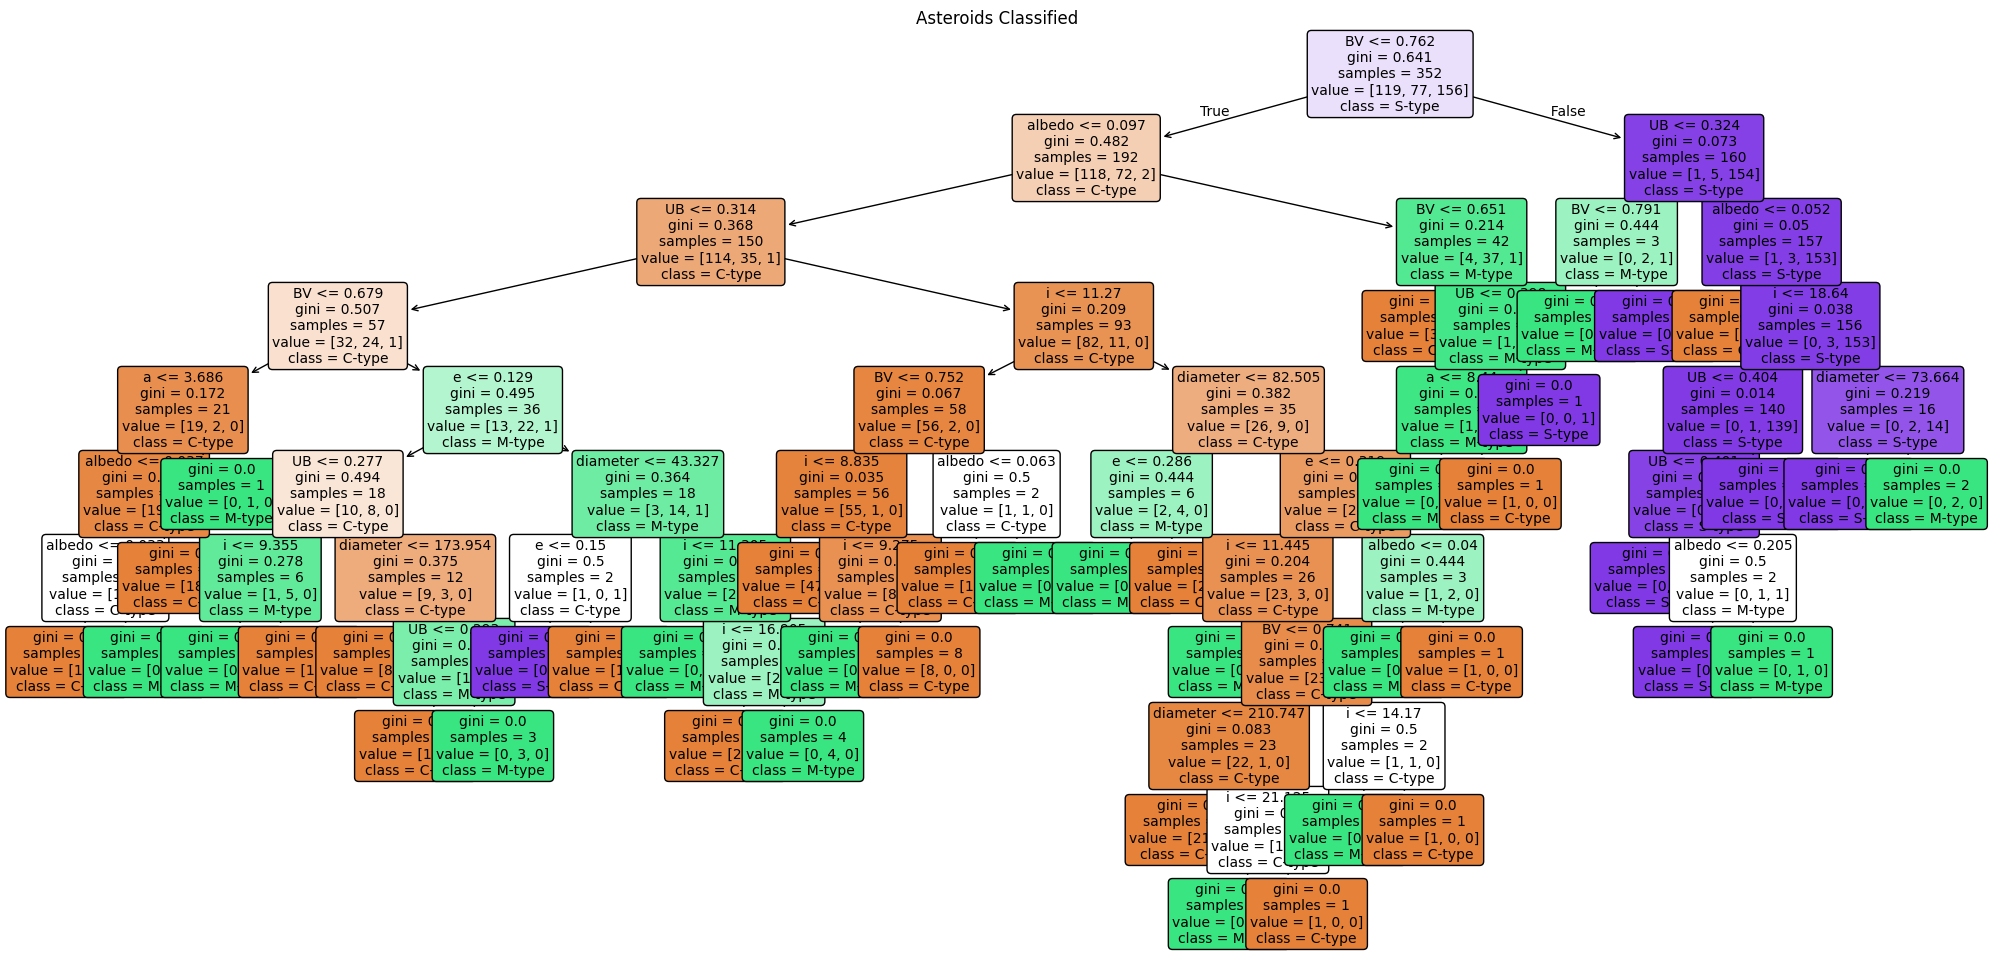

In [270]:
#Visualizing my decision tree
class_names = list(model.classes_)

plt.figure(figsize=(25, 12))

tree.plot_tree(model, 
               feature_names=features, 
               class_names=class_names, 
               filled=True,      
               rounded=True,     
               fontsize=10)      
plt.title('Asteroids Classified')
plt.show()

In [271]:
#Assesment accuracy (testing score), percision, recall, and training score
accuracy = metrics.accuracy_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred, average='weighted') #Needed to add the average='weighted' because it is not just a binary
trainscore = metrics.accuracy_score(y_train, model.predict(X_train))
f1 = metrics.f1_score(y_test, y_pred, average='weighted')

print('Weighted F1 Score:', f1)
print('Testing Score/Accuracy:', accuracy)
print('Precision:', precision)
print('Training score:', trainscore)

Weighted F1 Score: 0.8286488949646844
Testing Score/Accuracy: 0.8295454545454546
Precision: 0.829927034472489
Training score: 1.0


<Figure size 800x600 with 0 Axes>

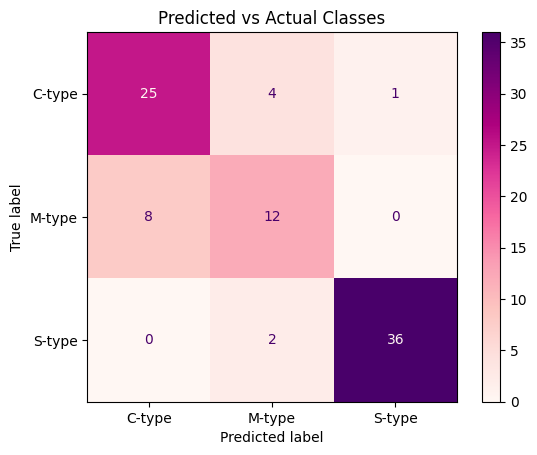

In [272]:
#Now I will plot a confusion matrix and learning curve to better understand the scores
#Imports for the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Plot the matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot(cmap='RdPu')
plt.title('Predicted vs Actual Classes')
plt.show()

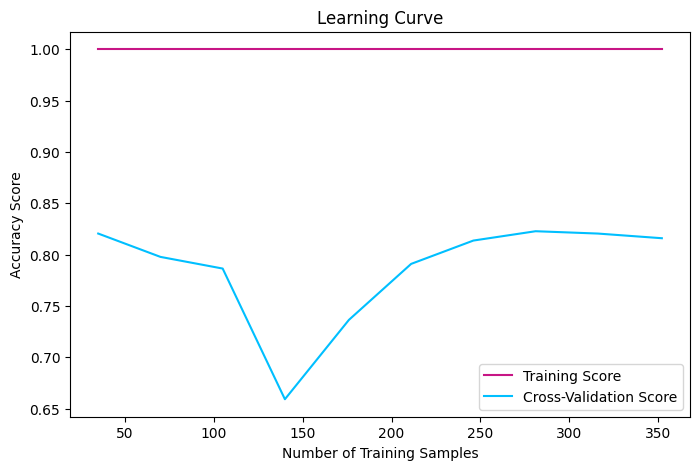

In [273]:
from sklearn.model_selection import learning_curve

#Learning curve data Ch6 HW style
train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10))

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

#Plot
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training Score', color='mediumvioletred')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', color='deepskyblue')

plt.title('Learning Curve')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy Score')
plt.legend()
plt.show()

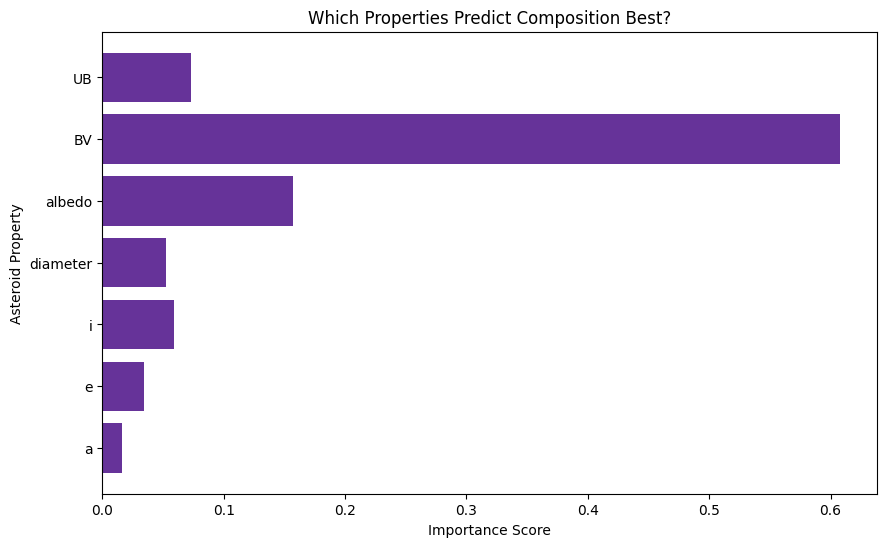

In [274]:
#Plot feature importance
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
features = ['a', 'e', 'i', 'diameter', 'albedo', 'BV', 'UB']

plt.barh(feature_names, importances, color='rebeccapurple')
plt.xlabel("Importance Score")
plt.ylabel("Asteroid Property")
plt.title("Which Properties Predict Composition Best?")
plt.show()